In [6]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

from src.world_cup_results import load_results_wc2026

meta_path = Path("model_output/simulation_runs_meta.json")
sim_path = Path("model_output/simulation_runs.jsonl")

with meta_path.open("r") as f:
    meta = json.load(f)

with sim_path.open("r") as f:
    simulation_rows = [json.loads(line) for line in f if line.strip()]

teams = meta["teams"]
team_to_id = {team: idx for idx, team in enumerate(teams)}
stages = meta["stages"]
stage_to_id = {stage: idx for idx, stage in enumerate(stages)}
group_stage_id = stage_to_id["Group"]
round_of_32_stage_id = stage_to_id["Round of 32"]
australia_id = team_to_id["Australia"]

groups_df = pd.read_csv("reference_data/world_cup_2026_groups.csv")
group_matches_df = pd.read_csv("reference_data/world_cup_2026_group_matches.csv")
results_wc2026 = load_results_wc2026()

australia_group = groups_df.loc[groups_df["team"] == "Australia", "group"].iloc[0]
locked_match_ids = set(results_wc2026.loc[results_wc2026["completed"], "match_id"])

candidate_matches = (
    group_matches_df.loc[
        (group_matches_df["group"] == australia_group)
        & (group_matches_df["home_team"] != "Australia")
        & (group_matches_df["away_team"] != "Australia")
        & (~group_matches_df["match_id"].isin(locked_match_ids))
    ]
    .copy()
    .reset_index(drop=True)
)

def australia_reaches_r32(sim_record):
    for match in sim_record["m"]:
        if match[0] != round_of_32_stage_id:
            continue
        if match[2] == australia_id or match[3] == australia_id:
            return True
    return False

def find_group_match_outcome(sim_record, home_id, away_id):
    for match in sim_record["m"]:
        if match[0] != group_stage_id:
            continue
        if match[2] == home_id and match[3] == away_id:
            home_score = int(match[4])
            away_score = int(match[5])
            if home_score > away_score:
                return "home_win"
            if away_score > home_score:
                return "away_win"
            return "draw"
    raise ValueError(f"Could not find simulated group match for home_id={home_id}, away_id={away_id}")

australia_r32_flags = np.array([australia_reaches_r32(sim) for sim in simulation_rows], dtype=bool)

records = []
for match in candidate_matches.itertuples(index=False):
    home_id = team_to_id[match.home_team]
    away_id = team_to_id[match.away_team]
    outcomes = [find_group_match_outcome(sim, home_id, away_id) for sim in simulation_rows]
    outcome_series = pd.Series(outcomes, name="outcome")

    counts = outcome_series.value_counts().reindex(["home_win", "draw", "away_win"], fill_value=0)
    advance_counts = pd.Series(
        {
            outcome: int(australia_r32_flags[outcome_series.eq(outcome).to_numpy()].sum())
            for outcome in ["home_win", "draw", "away_win"]
        }
    )
    non_advance_counts = counts - advance_counts

    contingency = np.vstack([advance_counts.to_numpy(), non_advance_counts.to_numpy()])
    observed_outcomes = int(counts.gt(0).sum())
    if observed_outcomes < 2:
        p_value = np.nan
    else:
        p_value = chi2_contingency(contingency, correction=False)[1]

    records.append(
        {
            "match_id": int(match.match_id),
            "match": f"{match.home_team} vs {match.away_team}",
            "home_team": match.home_team,
            "away_team": match.away_team,
            "n_home_win": int(counts["home_win"]),
            "n_draw": int(counts["draw"]),
            "n_away_win": int(counts["away_win"]),
            "p_australia_r32_given_home_win": float(advance_counts["home_win"] / counts["home_win"]) if counts["home_win"] else np.nan,
            "p_australia_r32_given_draw": float(advance_counts["draw"] / counts["draw"]) if counts["draw"] else np.nan,
            "p_australia_r32_given_away_win": float(advance_counts["away_win"] / counts["away_win"]) if counts["away_win"] else np.nan,
            "p_value_equal_probs": float(p_value) if pd.notna(p_value) else np.nan,
        }
    )

australia_group_match_matter_df = (
    pd.DataFrame(records)
    .sort_values("p_value_equal_probs", na_position="last")
    .reset_index(drop=True)
)

australia_group_match_matter_df

ValueError: Could not find simulated group match for home_id=194, away_id=202

In [1]:
import pandas as pd

df = pd.read_csv("model_output/ratings_history_yearly.csv")

In [8]:
df

,date,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wales,Yemen,Yugoslavia,Zambia,Zimbabwe
0,1872-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1874-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1875-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1876-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,85.869389,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,2022-01-01,22.362811,60.493831,79.494060,1.884506,25.994651,52.913022,4.510773,23.599641,97.254742,...,89.926541,62.150595,19.495424,76.140658,45.165748,78.933035,23.802888,NaN,55.823225,49.990674
151,2023-01-01,19.721285,67.240701,77.065295,1.038267,27.478390,51.400066,4.247123,16.728519,97.645158,...,93.037063,66.844938,18.021611,81.341710,44.765018,77.220383,25.681720,NaN,58.266576,52.151979
152,2024-01-01,22.084379,68.674304,76.152966,1.097059,26.119915,58.604779,4.097357,13.973183,97.622853,...,92.747274,67.102738,14.027282,80.570510,40.243236,78.075833,27.272137,NaN,56.912408,52.020020
153,2025-01-01,20.571926,69.633956,78.155024,1.095065,28.429439,56.068023,4.099092,14.132765,97.972845,...,91.150359,70.495844,15.553255,78.591074,37.322483,78.305203,32.278006,NaN,53.792276,50.503164


In [2]:
df["mu_sum"] = df["mu_attack"] + df["mu_defense"]
df["tilt"] = df["mu_attack"] - df["mu_defense"]

<Axes: ylabel='Frequency'>

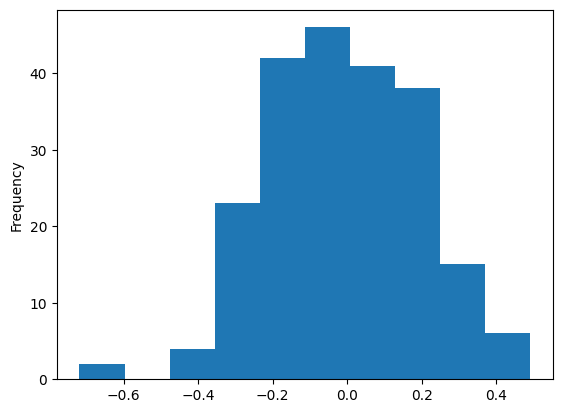

In [6]:
df.tilt.plot.hist()

In [19]:
df.sort_values("tilt", ascending=False).head(20)

,team,mu_attack,mu_defense,sigma_attack,sigma_defense,sigma_ad,mu_global,quality,quality_low,mu_attack_low,mu_defense_low,year,rating_attack,rating_defense,rating,mu_sum,tilt
187,St Vincent and the Grenadines,-1.398502,-1.890905,0.020310,0.018437,0.008615,0.265569,-3.289407,-3.762601,-1.683530,-2.162470,2026.0,31.989342,16.858501,23.533678,-3.289407,0.492403
22,Bermuda,-1.423362,-1.898133,0.020603,0.017695,0.007892,0.265569,-3.321495,-3.786603,-1.710436,-2.164177,2026.0,31.053398,16.688028,23.045508,-3.321495,0.474770
77,Germany,0.208238,-0.226568,0.014030,0.018789,0.008157,0.265569,-0.018330,-0.461655,-0.028656,-0.500717,2026.0,97.201333,85.702070,92.738463,-0.018330,0.434807
98,Israel,-0.361825,-0.784555,0.018194,0.016490,0.008487,0.265569,-1.146380,-1.600952,-0.631593,-1.041385,2026.0,80.193660,59.864269,70.381358,-1.146380,0.422729
147,Northern Mariana Islands,-2.961141,-3.352407,0.065210,0.030410,0.017955,0.265569,-6.313548,-7.038893,-3.471867,-3.701177,2026.0,3.098856,1.544665,2.197246,-6.313548,0.391266
10,Aruba,-1.683626,-2.059878,0.026655,0.021713,0.010288,0.265569,-3.743504,-4.268646,-2.010152,-2.354587,2026.0,22.362511,13.224527,17.317005,-3.743504,0.376252
87,Guyana,-1.177801,-1.538767,0.019576,0.020820,0.009284,0.265569,-2.716568,-3.202219,-1.457627,-1.827350,2026.0,41.066706,26.949556,33.541850,-2.716568,0.360965
14,Bahamas,-2.330663,-2.685133,0.031942,0.019298,0.009387,0.265569,-5.015796,-5.545003,-2.688112,-2.962967,2026.0,8.775050,4.953895,6.623703,-5.015796,0.354470
175,Sint Maarten,-1.869083,-2.218117,0.037602,0.023078,0.010326,0.265569,-4.087200,-4.657577,-2.256908,-2.521947,2026.0,17.381695,10.437279,13.543701,-4.087200,0.349035
109,Laos,-2.086331,-2.431170,0.027354,0.017553,0.010536,0.265569,-4.517500,-5.031227,-2.417109,-2.696148,2026.0,12.719231,7.490166,9.808328,-4.517500,0.344839
